In [1]:
# Run this cell to install all required libraries
!pip install tensorflow pillow matplotlib scipy scikit-learn


In [2]:
import tensorflow as tf
import numpy as np
import json
import os
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from pathlib import Path


In [3]:
# ============================================================
# 1) Parameters
# ============================================================

IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
EPOCHS = 50
NUM_TRAINABLE_LAYERS = 0  # Change to >0 for fine-tuning from the start

BASE_DIR = Path.cwd()

TRAIN_DATA_DIR = BASE_DIR / "Animals_Dataset_Splitted" / "train"
VALIDATION_DATA_DIR = BASE_DIR / "Animals_Dataset_Splitted" / "validation"
TEST_DATA_DIR = BASE_DIR / "Animals_Dataset_Splitted" / "test"


In [4]:
# ============================================================
# 2) Data Generators
# ============================================================

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
    VALIDATION_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)


Found 20938 images belonging to 10 classes.
Found 2614 images belonging to 10 classes.
Found 2627 images belonging to 10 classes.


In [5]:
# ============================================================
# 3) Class Mapping & Weights
# ============================================================

class_indices = train_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}


# Save class mapping
class_mapping_path = os.path.join(os.getcwd(), "mapeo_clases_MBNet.json")
with open(class_mapping_path, "w", encoding="utf-8") as f:
    json.dump({"class_indices": class_indices, "index_to_class": index_to_class}, f, indent=2)
print("Class mapping saved to:", class_mapping_path)

# Compute class weights to handle imbalance
num_classes = train_generator.num_classes

train_counts = {}
for class_name in class_indices:
    class_dir = os.path.join(TRAIN_DATA_DIR, class_name)
    train_counts[class_name] = len(os.listdir(class_dir))

total_train = sum(train_counts.values())

class_weight = {}
for class_name, class_index in class_indices.items():
    class_count = train_counts[class_name]
    class_weight[class_index] = total_train / (num_classes * class_count)

print("\nClass weights:")
for class_index, weight in class_weight.items():
    print(f"  {class_index} ({index_to_class[class_index]}): {weight:.4f}")


Class mapping saved to: C:\IA-FAC\mapeo_clases_MBNet.json
Class weights:
  0 (araña): 0.5430
  1 (ardilla): 1.4062
  2 (caballo): 0.9980
  3 (elefante): 1.8112
  4 (gallina): 0.8450
  5 (gato): 1.5696
  6 (mariposa): 1.2397
  7 (oveja): 1.4380
  8 (perro): 0.5383
  9 (vaca): 1.4034


In [6]:
# ============================================================
# 4) Load and Configure MobileNetV2
# ============================================================

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)
)

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

# Optionally unfreeze last N layers
if NUM_TRAINABLE_LAYERS > 0:
    for layer in base_model.layers[-NUM_TRAINABLE_LAYERS:]:
        layer.trainable = True

print("Total layers in MobileNetV2:", len(base_model.layers))
print("Trainable layers in MobileNetV2:", sum(1 for layer in base_model.layers if layer.trainable))


Total layers in MobileNetV2: 154
Trainable layers in MobileNetV2: 0


In [7]:
# ============================================================
# 5) Build and Compile Model
# ============================================================

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(train_generator.num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# ============================================================
# 6) Callbacks
# ============================================================

checkpoint_path = os.path.join(os.getcwd(), "mejor_modelo_MBNet.keras")

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, checkpoint, reduce_lr]


In [9]:
# ============================================================
# 7) Training
# ============================================================

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight
)


Epoch 1/50
Epoch 1: val_accuracy improved from None to 0.94147, saving model to C:\IA-FAC\mejor_modelo_MBNet.keras
Epoch 1: finished saving model to C:\IA-FAC\mejor_modelo_MBNet.keras
655/655 ━━━━━━━━━━━━━━━━━━━━ 367s 554ms/step - accuracy: 0.8355 - loss: 0.5588 - val_accuracy: 0.9415 - val_loss: 0.2171 - learning_rate: 1.0000e-04
Epoch 2/50
Epoch 2: val_accuracy improved from 0.94147 to 0.95065, saving model to C:\IA-FAC\mejor_modelo_MBNet.keras
Epoch 2: finished saving model to C:\IA-FAC\mejor_modelo_MBNet.keras
655/655 ━━━━━━━━━━━━━━━━━━━━ 362s 553ms/step - accuracy: 0.9265 - loss: 0.2514 - val_accuracy: 0.9507 - val_loss: 0.1707 - learning_rate: 1.0000e-04
Epoch 3/50
Epoch 3: val_accuracy did not improve from 0.95065
655/655 ━━━━━━━━━━━━━━━━━━━━ 362s 552ms/step - accuracy: 0.9318 - loss: 0.2231 - val_accuracy: 0.9499 - val_loss: 0.1718 - learning_rate: 1.0000e-04
Epoch 4/50
Epoch 4: val_accuracy did not improve from 0.95065
655/655 ━━━━━━━━━━━━━━━━━━━━ 361s 552ms/step - accuracy: 0

In [10]:
# ============================================================
# 8) Save Final Model
# ============================================================

final_model_path = os.path.join(os.getcwd(), "modelo_final_MBNet.keras")

model.save(final_model_path)

print("Final model saved to:", final_model_path)
print("Best model saved to:", checkpoint_path)
print("Class mapping saved to:", class_mapping_path)


Final model saved to: C:\IA-FAC\modelo_final_MBNet.keras
Best model saved to: C:\IA-FAC\mejor_modelo_MBNet.keras
Class mapping saved to: C:\IA-FAC\mapeo_clases_MBNet.json


In [11]:
# ============================================================
# 9) Evaluation on Test Set
# ============================================================

best_model = load_model(checkpoint_path)

test_loss, test_acc = best_model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Test Loss: 0.1414
Test Accuracy: 0.9558


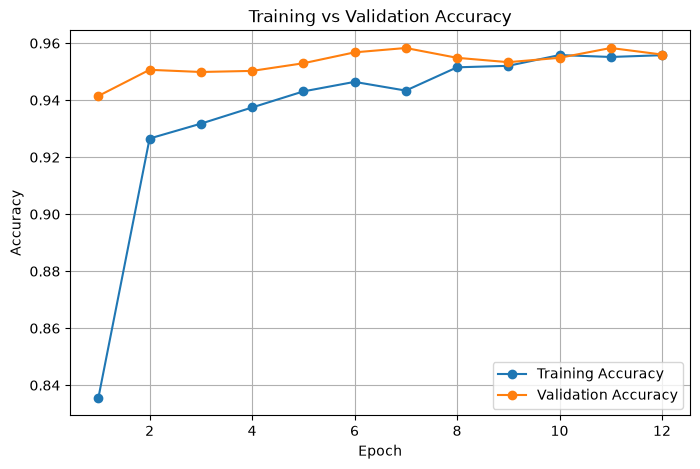

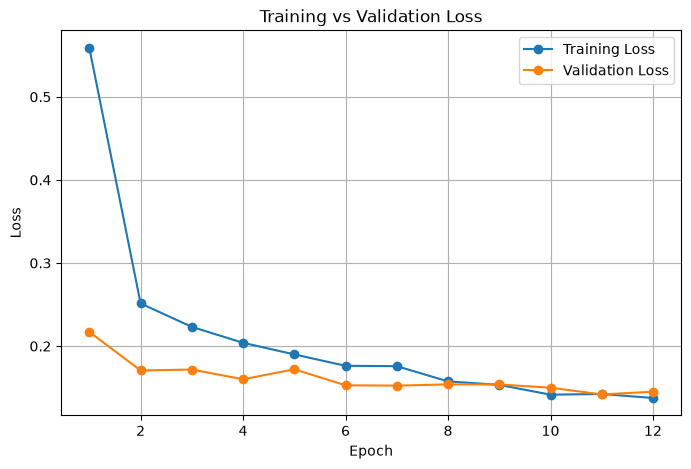

In [12]:
# ============================================================
# 10) Accuracy and Loss Graphs
# ============================================================

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(accuracy) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, accuracy, marker="o", label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, marker="o", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, marker="o", label="Training Loss")
plt.plot(epochs_range, val_loss, marker="o", label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


<Figure size 1000x1000 with 0 Axes>

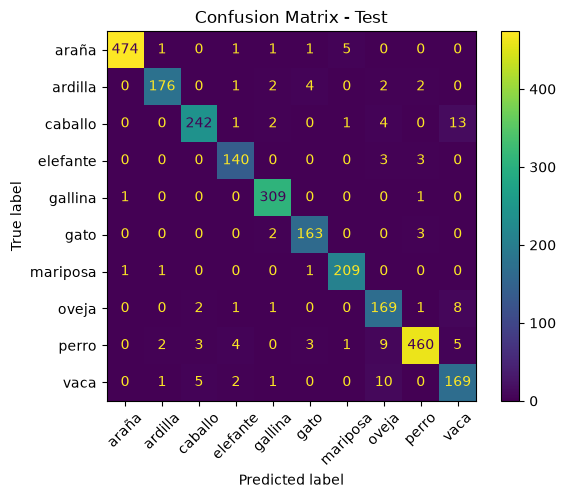

Classification Report:
              precision    recall  f1-score   support
       araña       1.00      0.98      0.99       483
     ardilla       0.97      0.94      0.96       187
     caballo       0.96      0.92      0.94       263
    elefante       0.93      0.96      0.95       146
     gallina       0.97      0.99      0.98       311
        gato       0.95      0.97      0.96       168
    mariposa       0.97      0.99      0.98       212
       oveja       0.86      0.93      0.89       182
       perro       0.98      0.94      0.96       487
        vaca       0.87      0.90      0.88       188
    accuracy                           0.96      2627
   macro avg       0.95      0.95      0.95      2627
weighted avg       0.96      0.96      0.96      2627


In [13]:
# ============================================================
# 11) Confusion Matrix and Classification Report
# ============================================================

test_generator.reset()

pred_probs = best_model.predict(test_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes

labels = list(range(train_generator.num_classes))
target_names = [index_to_class[i] for i in labels]

print("Classification Report:")
print(classification_report(y_true, y_pred, labels=labels, target_names=target_names))

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix - Test")
plt.show()


## Optional Fine-tuning

Run this section only after training with the frozen base first.

The idea is to unfreeze some final layers of MobileNetV2 and retrain with a lower `learning_rate`. This can improve results, but overdoing it can cause overfitting.


In [14]:
# ============================================================
# 12) Optional Fine-tuning
# ============================================================

RUN_FINE_TUNING = False

if RUN_FINE_TUNING:
    # Unfreeze only the last layers
    fine_tune_at = len(base_model.layers) - 30

    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    for layer in base_model.layers[fine_tune_at:]:
        layer.trainable = True

    # Keep BatchNormalization frozen for stable fine-tuning
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.summary()

    fine_tune_history = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=10,
        callbacks=callbacks,
        class_weight=class_weight
    )

    fine_tuned_model_path = os.path.join(os.getcwd(), "modelo_final_MBNet.keras")
    model.save(fine_tuned_model_path)

    print("Fine-tuned model saved to:", fine_tuned_model_path)
else:
    print("Fine-tuning disabled. Set RUN_FINE_TUNING = True to run it.")


Fine-tuning disabled. Set RUN_FINE_TUNING = True to run it.


In [15]:
# ============================================================
# 13) Individual Image Prediction
# ============================================================

from tensorflow.keras.preprocessing import image

def predict_image(img_path, model_path=checkpoint_path):
    loaded_model = load_model(model_path)

    img = image.load_img(img_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    pred = loaded_model.predict(img_array)
    pred_index = int(np.argmax(pred, axis=1)[0])
    confidence = float(np.max(pred))

    class_name = index_to_class[pred_index]

    print(f"Predicted class: {class_name} ({class_name})")
    print(f"Confidence: {confidence:.4f}")

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{class_name} - {confidence:.2%}")
    plt.show()

    return class_name, confidence

# Example usage:
# predict_image("Animals_Dataset_Splitted/test/gato/some_image.jpeg")
